In [4]:
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter

In [5]:
df = pd.read_csv(f'data/jackal/Orit_data.csv', na_values="NA", engine="python")
print("First data entry date:", df["dateTime_local"].min())
print("Last data entry date:", df["dateTime_local"].max())
print(df.shape)
df.head()

First data entry date: 2022-03-02 02:13:06
Last data entry date: 2022-03-08 03:59:57
(147542, 30)


,Unnamed: 0,TAG,TIME,X,Y,Z,lat,lon,VARX,VARY,...,month,Season,biological_season,Jackal_Name,Tag,dateTime_local,sunset,Night,estimated_age,Sex
0,274315,972006000707,1.646180e+12,238063.112478,715696.374140,-73,32.535297,35.402509,73.7185,165.4530,...,3,Spring,Breeding,Orit,707,2022-03-02 02:13:06,2022-03-02 17:39:20,1,Mature,Female
1,274319,972006000707,1.646180e+12,238059.783280,715694.529460,-73,32.535281,35.402474,88.9239,100.2080,...,3,Spring,Breeding,Orit,707,2022-03-02 02:13:09,2022-03-02 17:39:20,1,Mature,Female
2,274330,972006000707,1.646180e+12,238070.467245,715674.894732,-73,32.535104,35.402587,179.5890,168.5940,...,3,Spring,Breeding,Orit,707,2022-03-02 02:13:19,2022-03-02 17:39:20,1,Mature,Female
3,274335,972006000707,1.646180e+12,238065.106816,715694.332714,-73,32.535279,35.402531,80.0744,246.4330,...,3,Spring,Breeding,Orit,707,2022-03-02 02:13:23,2022-03-02 17:39:20,1,Mature,Female
4,274337,972006000707,1.646180e+12,238057.926020,715703.075113,-73,32.535358,35.402454,59.1482,97.1377,...,3,Spring,Breeding,Orit,707,2022-03-02 02:13:24,2022-03-02 17:39:20,1,Mature,Female


In [6]:
print(df['X'].max()-df['X'].min())
print(df['Y'].max()-df['Y'].min())

693.0629674689844
1092.5075471239397


In [7]:
df['biological_season'].unique()
parturition_df = df[df['biological_season'] == 'Parturition']
parturition_df.head()

,Unnamed: 0,TAG,TIME,X,Y,Z,lat,lon,VARX,VARY,...,month,Season,biological_season,Jackal_Name,Tag,dateTime_local,sunset,Night,estimated_age,Sex


In [8]:
df.drop(columns=["Speed_m_s"], inplace=True)

In [9]:
df.memory_usage(deep=True).sum() / 1024**2 # MB

np.float64(111.0179615020752)

In [10]:
df.columns

Index(['Unnamed: 0', 'TAG', 'TIME', 'X', 'Y', 'Z', 'lat', 'lon', 'VARX',
       'VARY', 'COVXY', 'NBS', 'PENALTY', 'dateTime', 'DAY', 'Outliers', 'STD',
       'geometry', 'date', 'month', 'Season', 'biological_season',
       'Jackal_Name', 'Tag', 'dateTime_local', 'sunset', 'Night',
       'estimated_age', 'Sex'],
      dtype='object')

In [11]:
df['Jackal_Name'].unique()

array(['Orit'], dtype=object)

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter


def make_trace_video(
    df,
    x_col="X",
    y_col="Y",
    time_col="dateTime_local",
    name_col="Jackal_Name",
    out_file="trace.mp4",
    batch_size=50,
    fps=15,
    interval=60
):

    # Copy and prepare data
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col)

    name = str(df[name_col].iloc[0])

    # Get bounds
    xmin, xmax = df[x_col].min(), df[x_col].max()
    ymin, ymax = df[y_col].min(), df[y_col].max()

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.axis("off")

    # Scatter plot
    scat = ax.scatter(
        [],
        [],
        s=2,
        c="#00ff00",
        alpha=0.7
    )

    # Text overlays
    time_text = ax.text(
        0.02, 0.95, "",
        transform=ax.transAxes,
        color="white",
        fontsize=10,
        ha="left",
        va="top"
    )

    name_text = ax.text(
        0.02, 0.90,
        f"Jackal: {name}",
        transform=ax.transAxes,
        color="white",
        fontsize=11,
        ha="left",
        va="top"
    )

    # Storage for points
    xs = []
    ys = []

    n = len(df)
    frames = list(range(0, n, batch_size))

    # Update function
    def update(i):

        start = frames[i]
        end = min(start + batch_size, n)

        chunk = df.iloc[start:end]

        xs.extend(chunk[x_col])
        ys.extend(chunk[y_col])

        scat.set_offsets(list(zip(xs, ys)))

        current_time = chunk[time_col].iloc[-1]

        time_text.set_text(
            current_time.strftime("%Y-%m-%d %H:%M:%S")
        )

        return scat, time_text, name_text

    # Create animation
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=True
    )

    # MP4 Writer
    writer = FFMpegWriter(
        fps=fps,
        codec="libx264",
        extra_args=[
            "-pix_fmt", "yuv420p",
            "-profile:v", "baseline",
            "-level", "3.0",
            "-movflags", "+faststart"
        ]
    )

    # Save video
    ani.save(
        out_file,
        writer=writer
    )

    plt.close(fig)

    print("Saved:", out_file)


In [13]:
def filter_on_date(df, low_date="2022-02-25", high_date="2022-02-26"):
    df = df[
        (df["dateTime_local"] >= low_date) &
        (df["dateTime_local"] <= high_date)
    ]
print("First data entry date:", df["dateTime_local"].min())
print("Last data entry date:", df["dateTime_local"].max())

First data entry date: 2022-03-02 02:13:06
Last data entry date: 2022-03-08 03:59:57


In [ ]:
make_trace_video(
    df,
    out_file=f"Orit_trace.mp4",
    batch_size=100
)

In [ ]:
df['TAG'].unique()

array([972006000707])

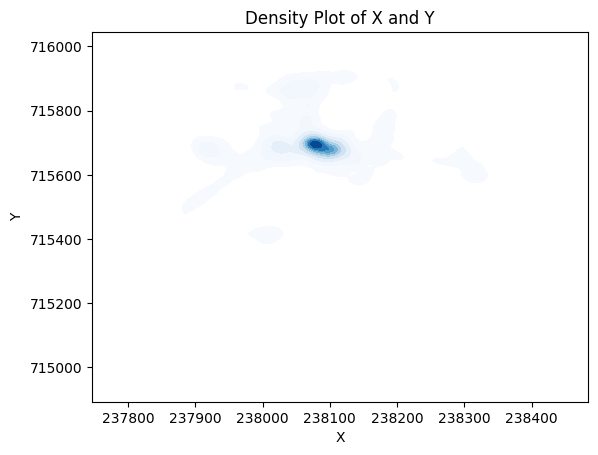

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Create a density plot for X and Y
sns.kdeplot(data=df, x='X', y='Y', cmap="Blues", fill=True)

# Add labels and title
plt.title('Density Plot of X and Y')
plt.xlabel('X')
plt.ylabel('Y')

# Show the plot
plt.show()

In [ ]:
hmm = MovementHMM(df.copy())
hmm.df

In [ ]:
best_k = hmm.run(k_min=2, k_max=6)

print("Best K:", best_k)

print(hmm.scores)

KeyError: 'dateTime'

In [ ]:
hmm.plot_k_scores()

hmm.plot_states(best_k)

hmm.plot_state_stats(best_k)

In [ ]:
%matplotlib tk
plot_all_ks(hmm, 3, 4)


K = 3

K = 4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler


class MovementHMM:
    """
    HMM pipeline adapted for wildlife GPS collar data (jackals).
    Includes segmentation, filtering, and biologically meaningful features.
    """

    def __init__(self, df):

        self.raw_df = df.copy()
        self.df = None

        self.features = None
        self.scaler = None

        self.models = {}
        self.scores = {}


    # --------------------------------------------------
    # Coordinate projection
    # --------------------------------------------------

    def project_coords(self):

        transformer = Transformer.from_crs(
            "EPSG:4326", "EPSG:32636", always_xy=True
        )

        x, y = transformer.transform(
            self.df["lon"].values,
            self.df["lat"].values
        )

        self.df["x"] = x
        self.df["y"] = y


    # --------------------------------------------------
    # Time preprocessing & segmentation
    # --------------------------------------------------

    def preprocess_time(self, max_gap_min=30):

        self.df["dateTime"] = pd.to_datetime(self.df["dateTime"])
        self.df = self.df.sort_values("dateTime")

        dt = self.df["dateTime"].diff().dt.total_seconds() / 60

        self.df["dt_min"] = dt

        # New segment if large gap
        self.df["new_segment"] = dt > max_gap_min

        self.df["segment"] = self.df["new_segment"].cumsum()

        # Remove cold-start points
        self.df = self.df[~self.df["new_segment"]]

        self.df = self.df.reset_index(drop=True)


    # --------------------------------------------------
    # Remove GPS jumps
    # --------------------------------------------------

    def filter_speed(self, vmax=8.0):

        dx = self.df["x"].diff()
        dy = self.df["y"].diff()

        dist = np.sqrt(dx**2 + dy**2)

        dt = self.df["dt_min"] * 60

        speed = dist / dt

        self.df["speed"] = speed

        mask = (speed < vmax) | (speed.isna())

        self.df = self.df[mask].reset_index(drop=True)


    # --------------------------------------------------
    # Detect resting / stops
    # --------------------------------------------------

    def add_stop_feature(self, window=5):

        vx = self.df["x"].rolling(window).var()
        vy = self.df["y"].rolling(window).var()

        loc_var = vx + vy

        self.df["loc_var"] = loc_var.bfill()


    # --------------------------------------------------
    # Feature computation (segment-aware)
    # --------------------------------------------------
    def compute_features(self, min_segment_len=15, window=5):

        feats = []

        for seg_id, seg in self.df.groupby("segment"):

            if len(seg) < min_segment_len:
                continue

            x = seg["x"].values
            y = seg["y"].values
            lv = seg["loc_var"].values

            dx = np.diff(x)
            dy = np.diff(y)

            steps = np.sqrt(dx**2 + dy**2)

            angles = np.arctan2(dy, dx)
            turns = np.diff(angles)

            # Normalize turns
            turns = (turns + np.pi) % (2*np.pi) - np.pi

            # Align lengths
            steps = steps[1:]
            turns = turns

            # Rolling stats
            df_feat = pd.DataFrame({
                "step": steps,
                "turn": turns,
                "loc_var": lv[2:]
            })

            # Rolling windows
            step_mean = df_feat["step"].rolling(window).mean()
            step_std  = df_feat["step"].rolling(window).std()

            turn_mean = df_feat["turn"].rolling(window).mean()
            turn_std  = df_feat["turn"].rolling(window).std()

            lv_mean = df_feat["loc_var"].rolling(window).mean()
            lv_std  = df_feat["loc_var"].rolling(window).std()

            feat_mat = np.column_stack([
                step_mean,
                step_std,
                turn_mean,
                turn_std,
                lv_mean,
                lv_std
            ])

            # Drop NaNs from rolling window
            feat_mat = feat_mat[~np.isnan(feat_mat).any(axis=1)]

            feats.append(feat_mat)

        if len(feats) == 0:
            raise ValueError("No valid trajectory segments found.")

        self.features = np.vstack(feats)


    # --------------------------------------------------
    # Fit HMM
    # --------------------------------------------------

    def fit_hmm(self, k, n_iter=500):

        model = GaussianHMM(
            n_components=k,
            covariance_type="full",
            n_iter=n_iter,
            random_state=42
        )

        model.fit(self.features)

        return model


    # --------------------------------------------------
    # Model selection (BIC)
    # --------------------------------------------------

    def compute_bic(self, model):

        k = model.n_components
        d = self.features.shape[1]
        n = len(self.features)

        # Parameter count
        n_params = (
            k * k +                  # transitions
            k * d +                  # means
            k * d * (d + 1) / 2       # covariances
        )

        logL = model.score(self.features)

        return -2 * logL + n_params * np.log(n)


    # --------------------------------------------------
    # Search over K
    # --------------------------------------------------

    def run_k_search(self, k_min=2, k_max=6):

        for k in range(k_min, k_max + 1):

            model = self.fit_hmm(k)

            self.models[k] = model

            self.scores[k] = {
                "logL": model.score(self.features),
                "bic": self.compute_bic(model)
            }


    # --------------------------------------------------
    # Best K
    # --------------------------------------------------

    def get_best_k(self):

        return min(
            self.scores,
            key=lambda k: self.scores[k]["bic"]
        )


    # --------------------------------------------------
    # Decode states
    # --------------------------------------------------

    def decode_states(self, k):

        return self.models[k].predict(self.features)


    # --------------------------------------------------
    # Plot states on map
    # --------------------------------------------------

    def plot_states(self, k):

        states = self.decode_states(k)

        # Align with features
        x = self.df["x"].values[2:len(states)+2]
        y = self.df["y"].values[2:len(states)+2]

        plt.figure(figsize=(7, 7))

        sc = plt.scatter(
            x, y,
            c=states,
            s=6,
            cmap="tab10"
        )

        plt.colorbar(sc)

        plt.title(f"HMM States (K={k})")

        plt.xlabel("X (m)")
        plt.ylabel("Y (m)")

        plt.show()


    # --------------------------------------------------
    # Plot feature distributions
    # --------------------------------------------------

    def plot_state_stats(self, k):

        states = self.decode_states(k)

        steps = self.features[:, 0]
        turns = self.features[:, 1]
        stops = self.features[:, 2]

        plt.figure(figsize=(14, 4))


        plt.subplot(1, 3, 1)

        for i in range(k):
            plt.hist(
                steps[states == i],
                bins=40,
                alpha=0.5,
                label=f"S{i}"
            )

        plt.title("Step Length")
        plt.legend()


        plt.subplot(1, 3, 2)

        for i in range(k):
            plt.hist(
                turns[states == i],
                bins=40,
                alpha=0.5,
                label=f"S{i}"
            )

        plt.title("Turning Angle")
        plt.legend()


        plt.subplot(1, 3, 3)

        for i in range(k):
            plt.hist(
                stops[states == i],
                bins=40,
                alpha=0.5,
                label=f"S{i}"
            )

        plt.title("Location Variance (Rest)")
        plt.legend()

        plt.tight_layout()
        plt.show()


    # --------------------------------------------------
    # Plot K selection
    # --------------------------------------------------

    def plot_k_scores(self):

        ks = sorted(self.scores.keys())

        bics = [self.scores[k]["bic"] for k in ks]
        lls = [self.scores[k]["logL"] for k in ks]

        plt.figure(figsize=(7, 4))

        plt.plot(ks, bics, "-o", label="BIC")
        plt.plot(ks, lls, "-o", label="LogL")

        plt.xlabel("K")
        plt.ylabel("Score")

        plt.legend()
        plt.title("Model Selection")

        plt.show()


    # --------------------------------------------------
    # Full pipeline
    # --------------------------------------------------

    def run(self, k_min=2, k_max=6):

        # Work on clean copy
        self.df = self.raw_df.copy()

        # Projection
        self.project_coords()

        # Time handling
        self.preprocess_time()

        # GPS filtering
        self.filter_speed()

        # Rest detection
        self.add_stop_feature()

        # Feature extraction
        self.compute_features()

        # Scaling
        self.scaler = StandardScaler()
        self.features = self.scaler.fit_transform(self.features)

        # Model search
        self.run_k_search(k_min, k_max)

        return self.get_best_k()


# PIGEON

In [ ]:
import pandas as pd
df = pd.read_csv('data/pigeon/animal_01.csv', na_values="", engine="python").dropna()
print(df.shape)
df.head()

(8815, 3)


,t,lat,lon
0,2525,32.778262,35.174679
1,2530,32.777219,35.174689
2,2535,32.775826,35.174674
3,2540,32.775926,35.174186
4,2545,32.776165,35.174387


In [ ]:
hmm = MovementHMM(df.copy())
hmm.df

In [ ]:
nan_rows = df[df.isna().any(axis=1)]
print(nan_rows)

Empty DataFrame
Columns: [t, lat, lon]
Index: []


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from pyproj import Transformer


class MovementHMM:

    def __init__(self, df):

        # self.csv_path = csv_path

        self.df = df.copy()
        self.features = None

        self.models = {}
        self.scores = {}


    def load_data(self):

        self.df = (
            pd.read_csv(self.csv_path, na_values="", engine="python")
              .dropna(subset=["lat", "lon"])
              .reset_index(drop=True)
        )


    def project_coords(self):

        transformer = Transformer.from_crs(
            "EPSG:4326", "EPSG:32636", always_xy=True
        )

        x, y = transformer.transform(
            self.df["lon"].values,
            self.df["lat"].values
        )

        self.df["x"] = x
        self.df["y"] = y


    def compute_features(self):

        x = self.df["x"].values
        y = self.df["y"].values

        dx = np.diff(x)
        dy = np.diff(y)

        steps = np.sqrt(dx**2 + dy**2)

        angles = np.arctan2(dy, dx)
        turns = np.diff(angles)

        turns = (turns + np.pi) % (2*np.pi) - np.pi

        self.features = np.column_stack([
            steps[1:],
            turns
        ])


    def fit_hmm(self, k, n_iter=500):

        model = GaussianHMM(
            n_components=k,
            covariance_type="full",
            n_iter=n_iter,
            random_state=42
        )

        model.fit(self.features)

        return model


    def compute_bic(self, model):

        logL = model.score(self.features)

        n_params = (
            model.n_components**2 +
            2 * model.n_components * self.features.shape[1]
        )

        n = len(self.features)

        return -2*logL + n_params*np.log(n)


    def run_k_search(self, k_min=2, k_max=6):

        for k in range(k_min, k_max + 1):

            model = self.fit_hmm(k)

            self.models[k] = model

            self.scores[k] = {
                "logL": model.score(self.features),
                "bic": self.compute_bic(model)
            }


    def get_best_k(self):

        return min(
            self.scores,
            key=lambda k: self.scores[k]["bic"]
        )


    def decode_states(self, k):

        return self.models[k].predict(self.features)


    def plot_states(self, k):

        states = self.decode_states(k)

        x = self.df["x"].values[2:]
        y = self.df["y"].values[2:]

        plt.figure(figsize=(7,7))

        sc = plt.scatter(
            x, y,
            c=states,
            s=6,
            cmap="tab10"
        )

        plt.colorbar(sc)

        plt.title(f"K = {k}")

        plt.xlabel("X")
        plt.ylabel("Y")

        plt.show()


    def plot_state_stats(self, k):

        states = self.decode_states(k)

        steps = self.features[:, 0]
        turns = self.features[:, 1]

        plt.figure(figsize=(12,4))


        plt.subplot(1,2,1)

        for i in range(k):

            plt.hist(
                steps[states == i],
                bins=40,
                alpha=0.5,
                label=f"S{i}"
            )

        plt.title("Step Lengths")
        plt.legend()


        plt.subplot(1,2,2)

        for i in range(k):

            plt.hist(
                turns[states == i],
                bins=40,
                alpha=0.5,
                label=f"S{i}"
            )

        plt.title("Turning Angles")
        plt.legend()

        plt.show()


    def plot_k_scores(self):

        ks = sorted(self.scores.keys())

        bics = [self.scores[k]["bic"] for k in ks]
        lls  = [self.scores[k]["logL"] for k in ks]

        plt.figure(figsize=(7,4))

        plt.plot(ks, bics, "-o", label="BIC")
        plt.plot(ks, lls,  "-o", label="LogL")

        plt.xlabel("K")
        plt.ylabel("Score")

        plt.legend()
        plt.title("Model Selection")

        plt.show()


    def run(self, k_min=2, k_max=6):

        # self.load_data()

        self.project_coords()

        self.compute_features()

        self.run_k_search(k_min, k_max)

        return self.get_best_k()

def plot_all_ks(hmm, k_min=2, k_max=6):

    for k in range(k_min, k_max + 1):

        print(f"\nK = {k}")

        hmm.plot_states(k)

        hmm.plot_state_stats(k)

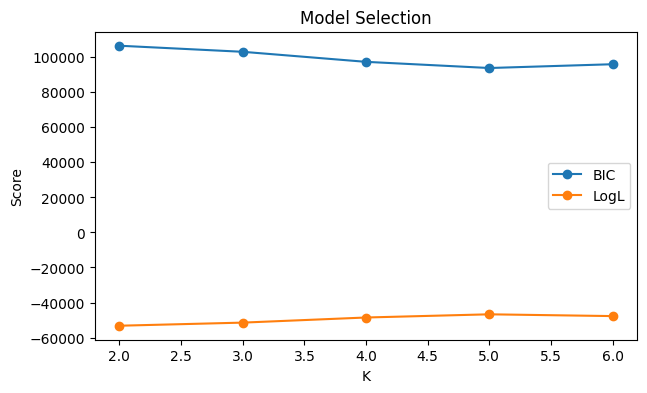

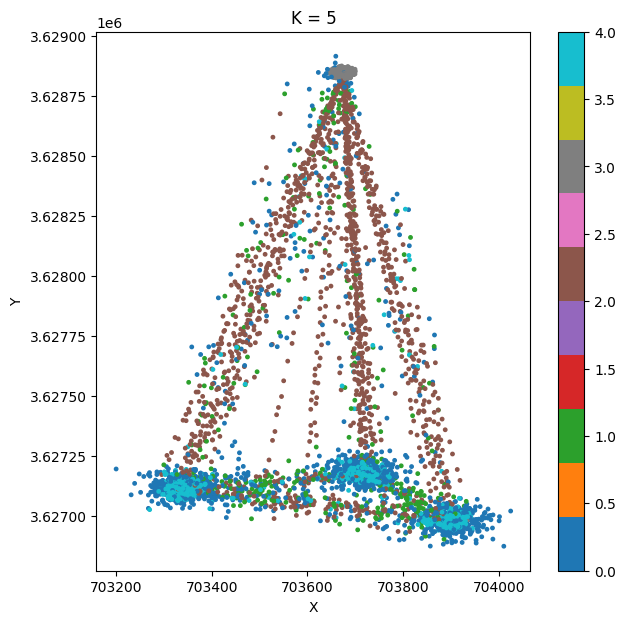

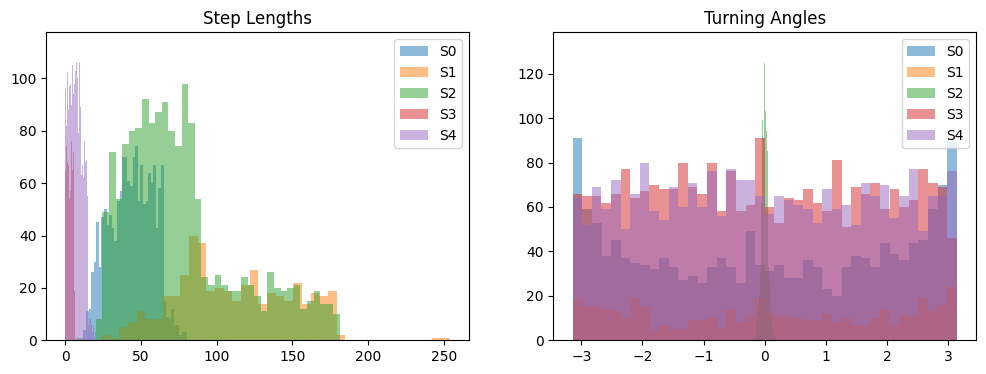

In [ ]:
hmm.plot_k_scores()

hmm.plot_states(best_k)

hmm.plot_state_stats(best_k)



K = 2


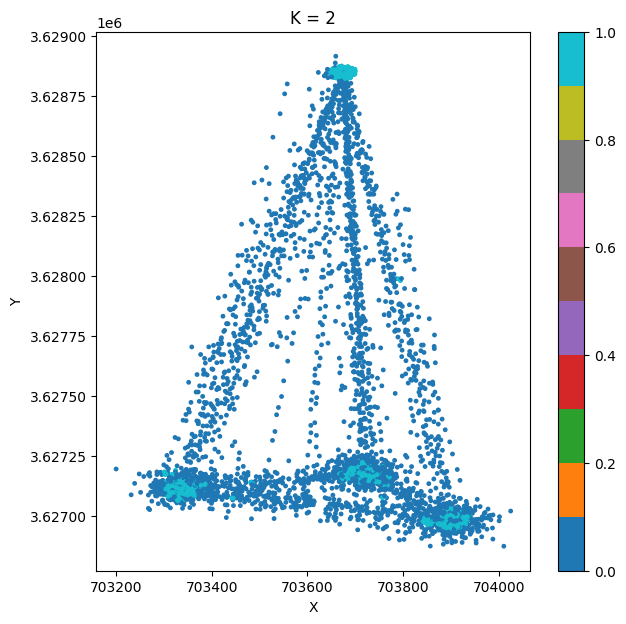

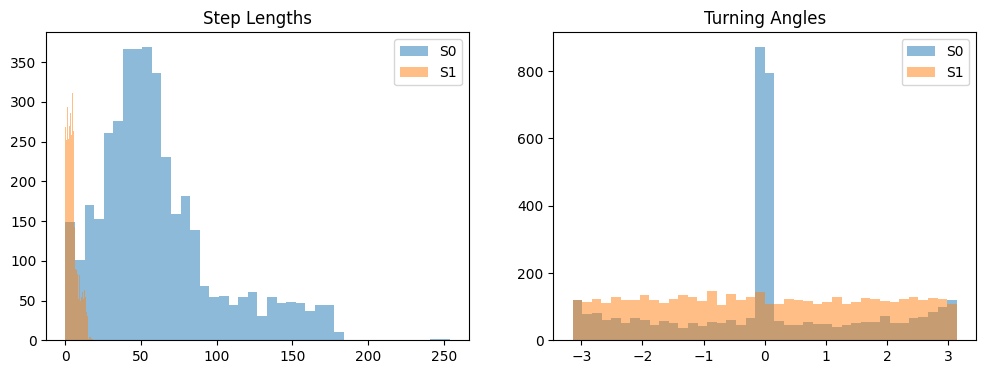


K = 3


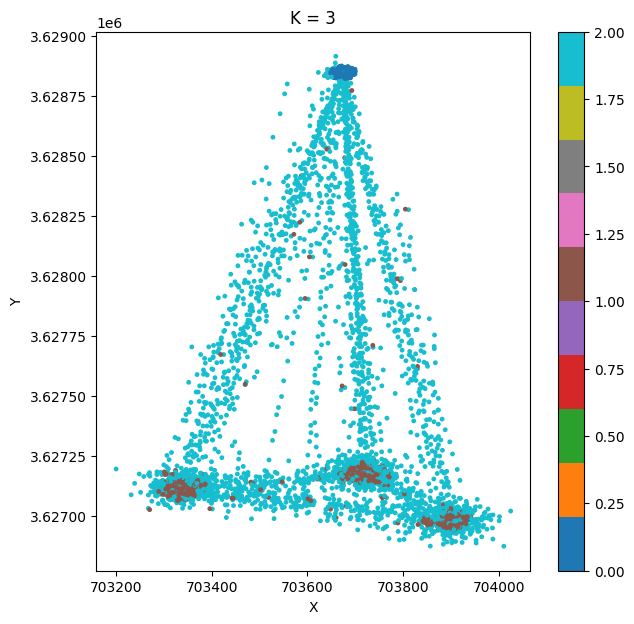

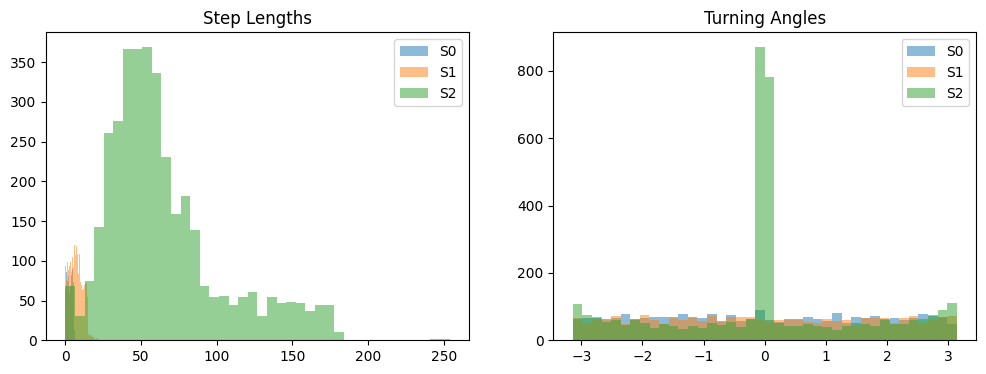


K = 4


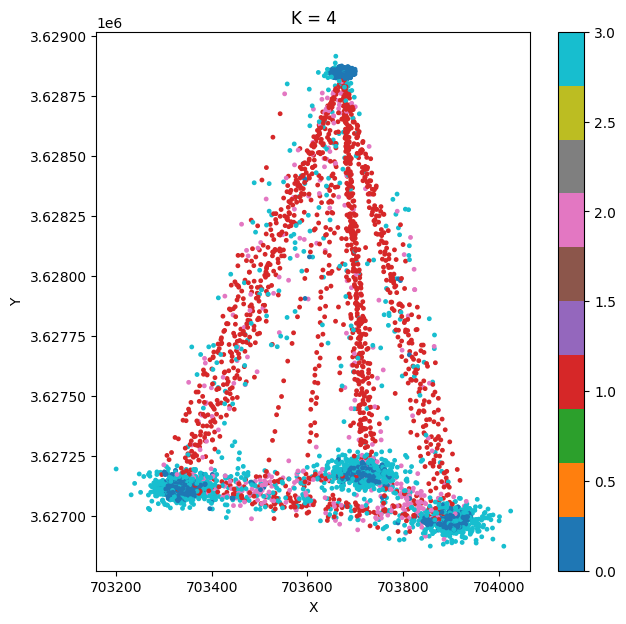

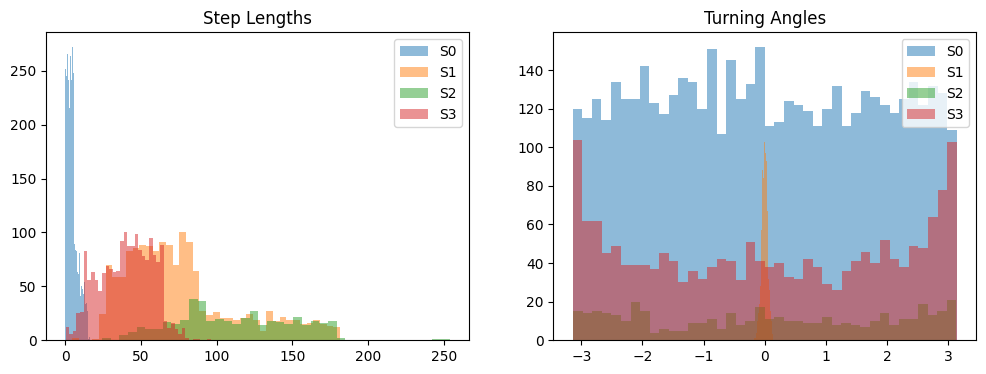


K = 5


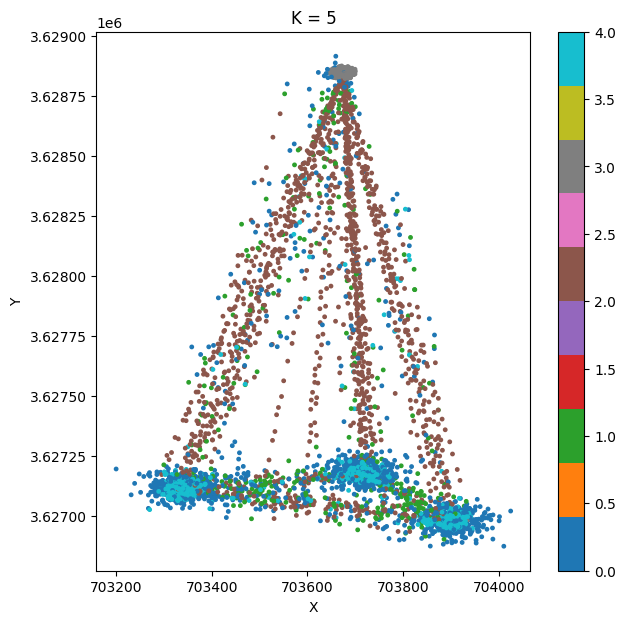

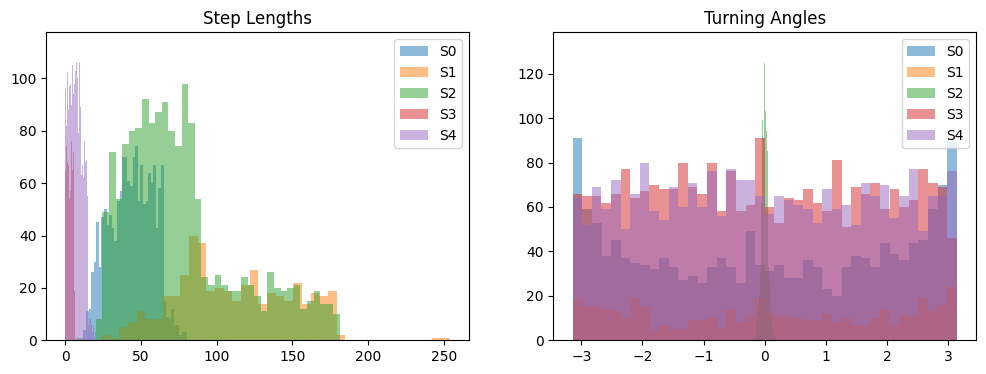


K = 6


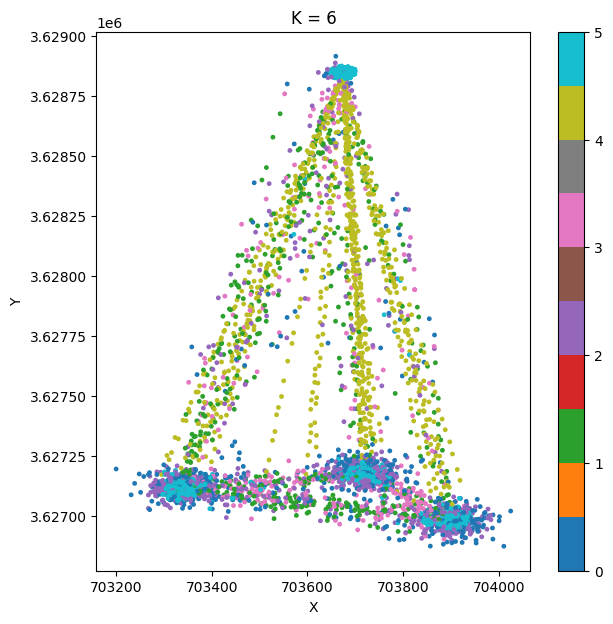

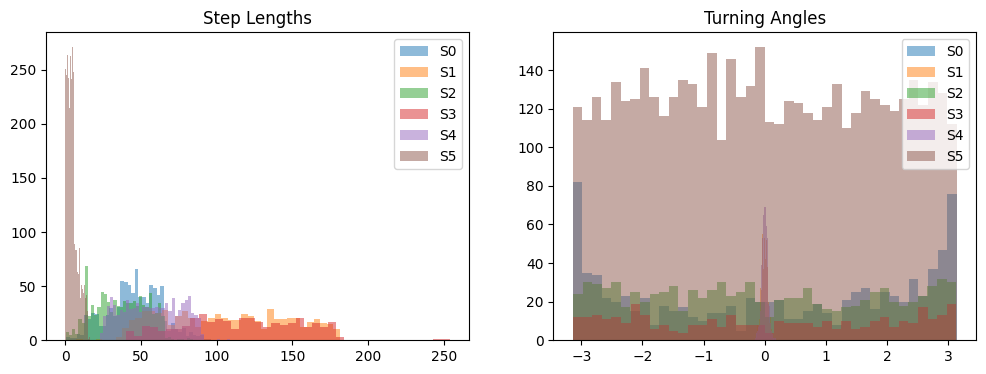

In [ ]:
plot_all_ks(hmm, 2, 6)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FFMpegWriter


def make_trace_video(
    df,
    x_col="x",
    y_col="y",
    out_file="trace.mp4",
    batch_size=50,
    fps=15,
    interval=60
):

    # Copy and prepare data
    df = df.copy()

    # Get bounds
    xmin, xmax = df[x_col].min(), df[x_col].max()
    ymin, ymax = df[y_col].min(), df[y_col].max()

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.axis("off")

    # Scatter plot
    scat = ax.scatter(
        [],
        [],
        s=2,
        c="#00ff00",
        alpha=0.7
    )

    # Storage for points
    xs = []
    ys = []

    n = len(df)
    frames = list(range(0, n, batch_size))

    # Update function
    def update(i):

        start = frames[i]
        end = min(start + batch_size, n)

        chunk = df.iloc[start:end]

        xs.extend(chunk[x_col])
        ys.extend(chunk[y_col])

        scat.set_offsets(list(zip(xs, ys)))

        return scat,

    # Create animation
    ani = animation.FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=True
    )

    # MP4 Writer
    writer = FFMpegWriter(
        fps=fps,
        codec="libx264",
        extra_args=[
            "-pix_fmt", "yuv420p",
            "-profile:v", "baseline",
            "-level", "3.0",
            "-movflags", "+faststart"
        ]
    )

    # Save video
    ani.save(
        out_file,
        writer=writer
    )

    plt.close(fig)

    print("Saved:", out_file)


In [ ]:
make_trace_video(hmm.df)

Saved: trace.mp4
